# Notebook 02: GARCH & DCC-GARCH Estimation

## Objective
Estimate univariate GARCH(p,q) models and Dynamic Conditional Correlation (DCC) GARCH for each asset.

## Inputs
- `../data/processed/all_assets_log_returns.csv` – Log-returns for 7 assets (2005–2025)

## Outputs
- `../outputs/garch_selected_models.csv` – Best GARCH model order (p,q) per asset
- `../outputs/dcc_correlations.csv` – Time-varying DCC correlation matrix
- `../outputs/all_assets_conditional_vol.csv` – GARCH conditional volatilities
- Figures: GARCH conditional volatilities, DCC correlation heatmaps

## 1. GARCH Model Selection

In [1]:
import pandas as pd
from arch import arch_model
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from pathlib import Path

# Setup paths
DATA_DIR = Path('../data/processed')
OUTPUT_DIR = Path('../outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Load your cleaned log-returns
lr = pd.read_csv(DATA_DIR / "all_assets_log_returns.csv", parse_dates=["Date"], index_col="Date")

results = []
p_vals = [1, 2, 3, 4, 5]
q_vals = [1, 2, 3, 4, 5]

for asset in lr.columns:
    series = lr[asset].dropna() * 100  # scale up
    
    # ARCH LM test
    arch_p = het_arch(series, nlags=10)[1]
    if arch_p >= 0.05:
        print(f"{asset}: no ARCH effects (p={arch_p:.3f}), skipping GARCH.")
        continue
    
    # Ljung-Box for mean specification
    lb_p = acorr_ljungbox(series, lags=[5], return_df=True)["lb_pvalue"].iloc[0]
    if lb_p < 0.05:
        mean_spec, lags = "AR", 1
    else:
        mean_spec, lags = "Constant", 0
    
    best_aic = float("inf")
    best_order = None
    
    for p in p_vals:
        for q in q_vals:
            try:
                am = arch_model(series, mean=mean_spec, lags=lags,
                                vol="GARCH", p=p, q=q, dist="normal")
                res = am.fit(disp="off")
                if res.aic < best_aic:
                    best_aic = res.aic
                    best_order = (p, q)
                    best_res = res
            except Exception:
                pass
    
    results.append({
        "Asset": asset,
        "Mean_Spec": f"{mean_spec}({lags})",
        "Best_p": best_order[0],
        "Best_q": best_order[1],
        "Best_AIC": best_aic
    })
    print(f"{asset}: {mean_spec}({lags}), Best GARCH{best_order} AIC={best_aic:.1f}")

# Summary
best_df = pd.DataFrame(results).set_index("Asset")
best_df.to_csv(OUTPUT_DIR / "garch_selected_models.csv")
print(f"\n✓ Saved GARCH model selection to '{OUTPUT_DIR}/garch_selected_models.csv'")
print(best_df)

S&P_500: AR(1), Best GARCH(4, 2) AIC=13661.8
IEF: AR(1), Best GARCH(1, 1) AIC=4984.1
Gold: Constant(0), Best GARCH(1, 1) AIC=14818.7
Crude_Oil: AR(1), Best GARCH(1, 1) AIC=22199.0
Natural_Gas: AR(1), Best GARCH(5, 5) AIC=26451.9
Wheat: Constant(0), Best GARCH(1, 1) AIC=21371.3
PBW: AR(1), Best GARCH(2, 2) AIC=21301.0

✓ Saved GARCH model selection to '..\outputs/garch_selected_models.csv'
               Mean_Spec  Best_p  Best_q      Best_AIC
Asset                                                 
S&P_500            AR(1)       4       2  13661.799600
IEF                AR(1)       1       1   4984.057479
Gold         Constant(0)       1       1  14818.711912
Crude_Oil          AR(1)       1       1  22198.982667
Natural_Gas        AR(1)       5       5  26451.906615
Wheat        Constant(0)       1       1  21371.332868
PBW                AR(1)       2       2  21300.962784


In [2]:
print(best_res.summary())


                           AR - GARCH Model Results                           
Dep. Variable:                    PBW   R-squared:                      -0.000
Mean Model:                        AR   Adj. R-squared:                 -0.000
Vol Model:                      GARCH   Log-Likelihood:               -10643.5
Distribution:                  Normal   AIC:                           21301.0
Method:            Maximum Likelihood   BIC:                           21346.7
                                        No. Observations:                 5099
Date:                Sun, Feb 08 2026   Df Residuals:                     5097
Time:                        13:04:05   Df Model:                            2
                                  Mean Model                                 
                 coef    std err          t      P>|t|       95.0% Conf. Int.
-----------------------------------------------------------------------------
Const          0.0237  2.427e-02      0.978      0.328 

In [3]:
import pandas as pd
from arch import arch_model
from pathlib import Path

# Setup paths
DATA_DIR = Path('../data/processed')
OUTPUT_DIR = Path('../outputs')

# Load your cleaned log-returns
lr = pd.read_csv(DATA_DIR / "all_assets_log_returns.csv", parse_dates=["Date"], index_col="Date")

# Dictionary to hold conditional vols
cond_vol = {}

# Your best orders per asset:
best_orders = {
    "S&P_500": (4,2), 
    "IEF":     (1,1),
    "Gold":    (1,1),
    "Wheat":   (1,1),
    "Natural_Gas": (5,5),
    "Crude_Oil":   (1,1),
    "PBW":     (2,2)
}
# And mean specs as determined earlier:
mean_specs = {
    "S&P_500": ("AR",1),
    "IEF":     ("AR",1),
    "Gold":    ("Constant",0),
    "Wheat":   ("Constant",0),
    "Natural_Gas": ("AR",1),
    "Crude_Oil":   ("AR",1),
    "PBW":     ("AR",1)
}

for asset in lr.columns:
    series = lr[asset].dropna() * 100
    mean_spec, lags = mean_specs[asset]
    p, q = best_orders[asset]
    
    am = arch_model(
        series,
        mean=mean_spec,
        lags=lags,
        vol="GARCH",
        p=p,
        q=q,
        dist="normal"
    )
    res = am.fit(disp="off")
    cond_vol[asset] = res.conditional_volatility

vol_df = pd.DataFrame(cond_vol)
vol_df.to_csv(OUTPUT_DIR / "all_assets_conditional_vol.csv")
print(f"✓ Saved conditional volatilities to '{OUTPUT_DIR}/all_assets_conditional_vol.csv'")

✓ Saved conditional volatilities to '..\outputs/all_assets_conditional_vol.csv'


In [4]:
import pandas as pd
from mgarch import mgarch
import inspect
from pathlib import Path

# Setup paths
DATA_DIR = Path('../data/processed')

# Load a small sample so it runs quickly
ret_df = pd.read_csv(DATA_DIR / "all_assets_log_returns.csv", parse_dates=["Date"], index_col="Date")
rt = ret_df.values[:50]

# Fit the model
model = mgarch(dist="norm")
model.fit(rt)

# Show the signature and docstring of predict
print("Signature:\n", inspect.signature(model.predict))
print("\nDocstring:\n", model.predict.__doc__)

Signature:
 (ndays=1)

Docstring:
 None


In [5]:
import pandas as pd
import numpy as np
from mgarch import mgarch
from pathlib import Path

# Setup paths
DATA_DIR = Path('../data/processed')
OUTPUT_DIR = Path('../outputs')

# 1) Load your cleaned returns
ret_df = pd.read_csv(DATA_DIR / "all_assets_log_returns.csv",
                     parse_dates=["Date"], index_col="Date")

rt = ret_df.values  # shape T x N

# 2) Initialize and fit the mgarch model
model = mgarch(dist="norm")
model.fit(rt)

# 3) Get conditional volatilities and standardized residuals
D_t = model.D_t         # (T x N) conditional std. dev.
eps = rt / D_t          # standardized residuals, shape (T x N)

# 4) Since a, b are not automatically estimated, we need to estimate them manually
# or use default DCC parameters
# Option A: Use typical DCC parameters from literature
a = 0.01  # DCC alpha parameter (typical range: 0.01-0.05)
b = 0.95  # DCC beta parameter (typical range: 0.90-0.98)

# Option B: Estimate DCC parameters (more complex, simplified version below)
# We'll use the simple approach with literature values

print(f"Using DCC parameters: a={a}, b={b}")

# 5) Compute unconditional covariance of standardized residuals
Qbar = np.cov(eps, rowvar=False)
print(f"Unconditional correlation matrix shape: {Qbar.shape}")

# 6) Run DCC recursion
T, N = eps.shape
Qt = Qbar.copy()  # Initialize Q_0 = Qbar
Rt = np.zeros((T, N, N))

print(f"Running DCC recursion for {T} time periods and {N} assets...")

for t in range(T):
    if t > 0:
        # Get previous period's standardized residuals
        ep = eps[t-1][:, None]  # Column vector
        # Update Qt: Qt = (1-a-b)*Qbar + a*(eps_{t-1} * eps_{t-1}') + b*Qt_{t-1}
        Qt = (1 - a - b) * Qbar + a * (ep @ ep.T) + b * Qt
    
    # Convert Qt to correlation matrix Rt
    # Rt = D^{-1} * Qt * D^{-1} where D = diag(sqrt(diag(Qt)))
    sqrt_diag = np.sqrt(np.diag(Qt))
    # Avoid division by zero
    sqrt_diag = np.where(sqrt_diag == 0, 1e-8, sqrt_diag)
    inv_sqrt = np.diag(1 / sqrt_diag)
    Rt[t] = inv_sqrt @ Qt @ inv_sqrt
    
    # Ensure diagonal elements are exactly 1 (numerical precision)
    np.fill_diagonal(Rt[t], 1.0)

print("DCC recursion completed!")

# 7) Flatten for export - include all correlations (upper triangle)
dates = ret_df.index
assets = ret_df.columns.tolist()
records = []

for t in range(T):
    for i in range(N):
        for j in range(i, N):  # Include diagonal (i=j) and upper triangle (i<j)
            if i == j:
                pair_name = f"{assets[i]}"  # Self-correlation (should be 1)
            else:
                pair_name = f"{assets[i]}–{assets[j]}"
            
            records.append({
                "Date": dates[t].strftime("%Y-%m-%d"),
                "Asset1": assets[i],
                "Asset2": assets[j], 
                "Pair": pair_name,
                "Correlation": Rt[t, i, j]
            })

corr_df = pd.DataFrame(records)
corr_df.to_csv(OUTPUT_DIR / "dcc_correlations.csv", index=False)

print(f"✓ Saved DCC correlations to '{OUTPUT_DIR}/dcc_correlations.csv'")
print(f"Total records: {len(records)}")
print(f"Date range: {dates[0].strftime('%Y-%m-%d')} to {dates[-1].strftime('%Y-%m-%d')}")

# 8) Display some sample correlations
print("\nSample correlations (first 10 rows):")
print(corr_df.head(10))

# 9) Summary statistics for off-diagonal correlations only
off_diagonal = corr_df[corr_df['Asset1'] != corr_df['Asset2']]
print(f"\nCorrelation summary statistics (excluding diagonal):")
print(f"Mean correlation: {off_diagonal['Correlation'].mean():.4f}")
print(f"Std correlation: {off_diagonal['Correlation'].std():.4f}")
print(f"Min correlation: {off_diagonal['Correlation'].min():.4f}")
print(f"Max correlation: {off_diagonal['Correlation'].max():.4f}")

Using DCC parameters: a=0.01, b=0.95
Unconditional correlation matrix shape: (7, 7)
Running DCC recursion for 5100 time periods and 7 assets...
DCC recursion completed!
✓ Saved DCC correlations to '..\outputs/dcc_correlations.csv'
Total records: 142800
Date range: 2005-03-04 to 2025-06-27

Sample correlations (first 10 rows):
         Date   Asset1       Asset2                 Pair  Correlation
0  2005-03-04  S&P_500      S&P_500              S&P_500     1.000000
1  2005-03-04  S&P_500          IEF          S&P_500–IEF    -0.267862
2  2005-03-04  S&P_500         Gold         S&P_500–Gold     0.026774
3  2005-03-04  S&P_500    Crude_Oil    S&P_500–Crude_Oil     0.252032
4  2005-03-04  S&P_500  Natural_Gas  S&P_500–Natural_Gas     0.044780
5  2005-03-04  S&P_500        Wheat        S&P_500–Wheat     0.077248
6  2005-03-04  S&P_500          PBW          S&P_500–PBW     0.690158
7  2005-03-04      IEF          IEF                  IEF     1.000000
8  2005-03-04      IEF         Gold       

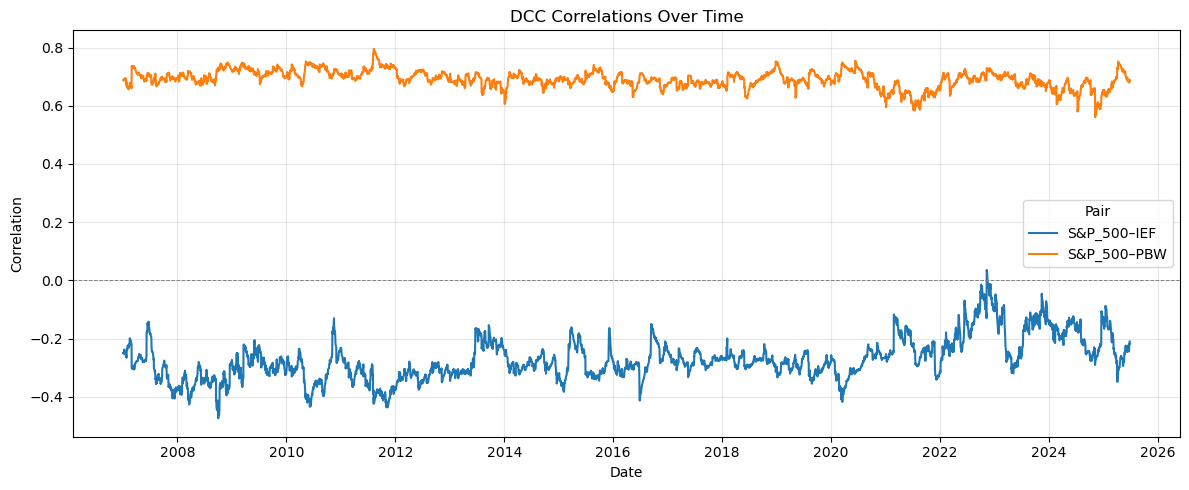

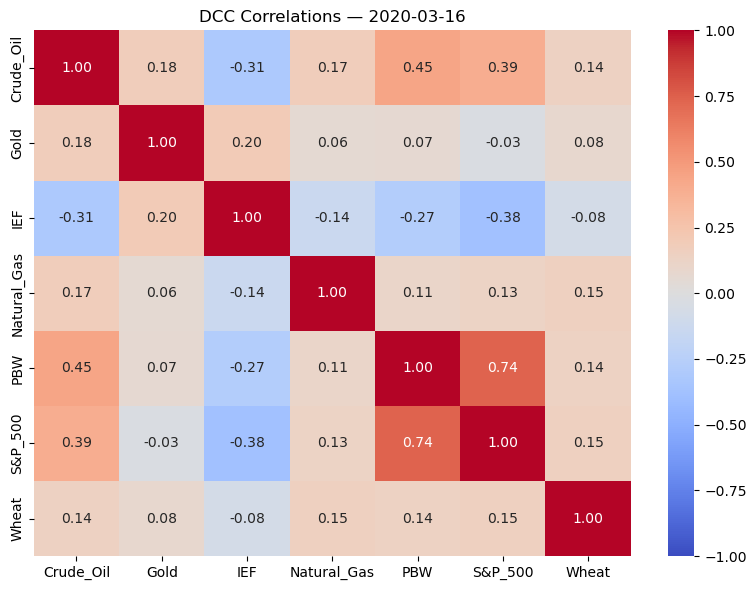

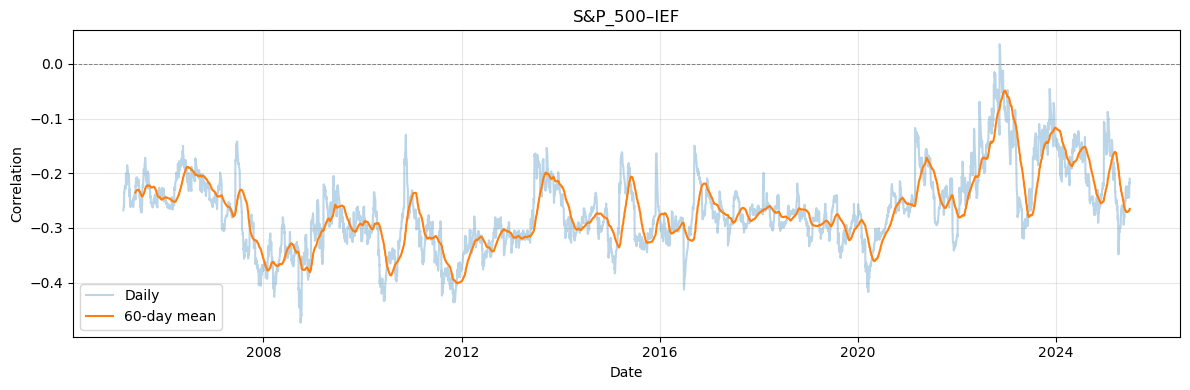

C:\Users\hobso\AppData\Local\Temp\ipykernel_9092\1216896875.py:106: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=summary["mean"], y=summary.index, palette="coolwarm")


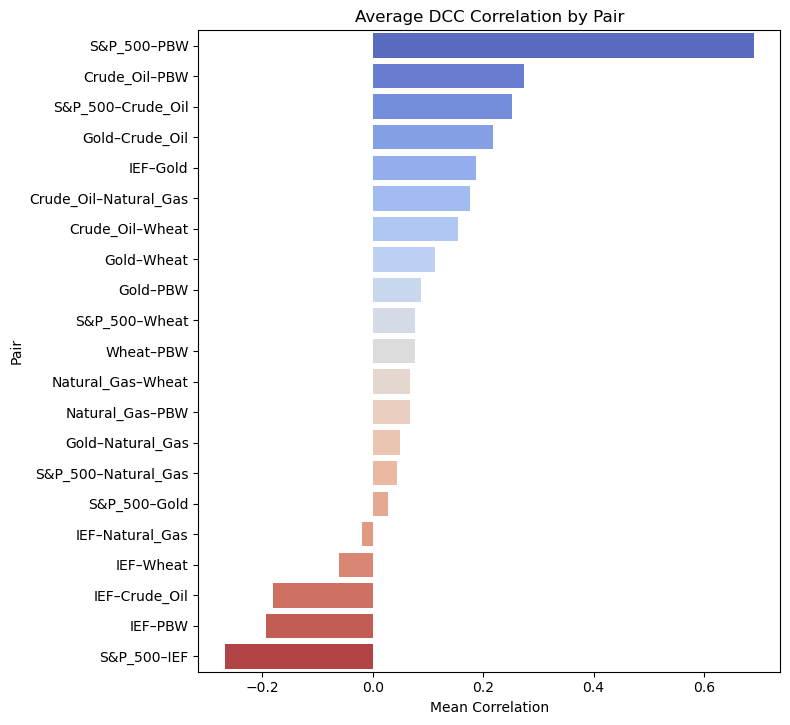

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from pathlib import Path

# Setup paths
OUTPUT_DIR = Path('../outputs')

corr = pd.read_csv(OUTPUT_DIR / "dcc_correlations.csv", parse_dates=["Date"])

# --- Ensure a clean 'Pair' column and drop self-pairs/invalid rows ---
if "Pair" not in corr.columns:
    if {"Asset1","Asset2"}.issubset(corr.columns):
        corr["Pair"] = corr["Asset1"].astype(str) + "–" + corr["Asset2"].astype(str)
    else:
        raise ValueError("Input must contain either a 'Pair' column or both 'Asset1' and 'Asset2'.")

# Keep only rows that look like 'A–B' or 'A-B' (no solitary asset names)
pair_pattern = r".+\s*[–-]\s*.+"
corr = corr[corr["Pair"].astype(str).str.fullmatch(pair_pattern)]
corr = corr.dropna(subset=["Date","Correlation","Pair"])

# Helper to split asset pairs (handles hyphen or en dash, any spaces)
def split_pair(p):
    parts = re.split(r"\s*[–-]\s*", str(p).strip())
    return parts if len(parts) == 2 else [None, None]

# --------------------- Plots ---------------------
def plot_pairs_seaborn(corr, pairs, start=None, end=None):
    df = corr[corr["Pair"].isin(pairs)].copy()
    if start: df = df[df["Date"] >= pd.to_datetime(start)]
    if end:   df = df[df["Date"] <= pd.to_datetime(end)]

    if df.empty:
        print("No data for the requested pairs / dates.")
        return

    plt.figure(figsize=(12,5))
    sns.lineplot(data=df, x="Date", y="Correlation", hue="Pair")
    plt.axhline(0, ls="--", c="gray", lw=0.7)
    plt.title("DCC Correlations Over Time")
    plt.ylabel("Correlation")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example:
plot_pairs_seaborn(corr, ["S&P_500–PBW", "S&P_500–IEF"], start="2007-01-01")

def plot_heatmap_seaborn(corr, date):
    # nearest available date
    date = pd.to_datetime(date)
    nearest_date = corr.iloc[(corr["Date"] - date).abs().argsort()[:1]]["Date"].iloc[0]
    df = corr[corr["Date"] == nearest_date].copy()

    # Build list of assets from valid pairs
    pairs = df["Pair"].dropna().astype(str)
    assets = sorted({a for p in pairs for a in split_pair(p) if a})
    if not assets:
        print("No valid pairs found for the selected date.")
        return

    # Initialize correlation matrix with 1s on the diagonal
    mat = pd.DataFrame(1.0, index=assets, columns=assets)

    # Fill off-diagonals from pairs
    for _, row in df.iterrows():
        a, b = split_pair(row["Pair"])
        if a and b and a in assets and b in assets:
            mat.loc[a, b] = row["Correlation"]
            mat.loc[b, a] = row["Correlation"]

    plt.figure(figsize=(8,6))
    sns.heatmap(mat, vmin=-1, vmax=1, cmap="coolwarm", annot=True, fmt=".2f")
    plt.title(f"DCC Correlations — {pd.to_datetime(nearest_date).date()}")
    plt.tight_layout()
    plt.show()

# Example:
plot_heatmap_seaborn(corr, "2020-03-16")

def plot_rolling_seaborn(corr, pair, window=60):
    df = corr[corr["Pair"] == pair].copy().sort_values("Date")
    if df.empty:
        print(f"No data for pair: {pair}")
        return
    df["Rolling"] = df["Correlation"].rolling(window).mean()

    plt.figure(figsize=(12,4))
    sns.lineplot(x="Date", y="Correlation", data=df, alpha=0.3, label="Daily")
    sns.lineplot(x="Date", y="Rolling", data=df, label=f"{window}-day mean")
    plt.axhline(0, ls="--", c="gray", lw=0.7)
    plt.title(pair)
    plt.ylabel("Correlation")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example:
plot_rolling_seaborn(corr, "S&P_500–IEF", window=60)

# --------------------- Summary chart ---------------------
summary = corr.groupby("Pair", as_index=True)["Correlation"].agg(["mean","std","min","max"]).sort_values("mean", ascending=False)
plt.figure(figsize=(8, max(4, 0.35*len(summary))))
sns.barplot(x=summary["mean"], y=summary.index, palette="coolwarm")
plt.title("Average DCC Correlation by Pair")
plt.xlabel("Mean Correlation")
plt.tight_layout()
plt.show()

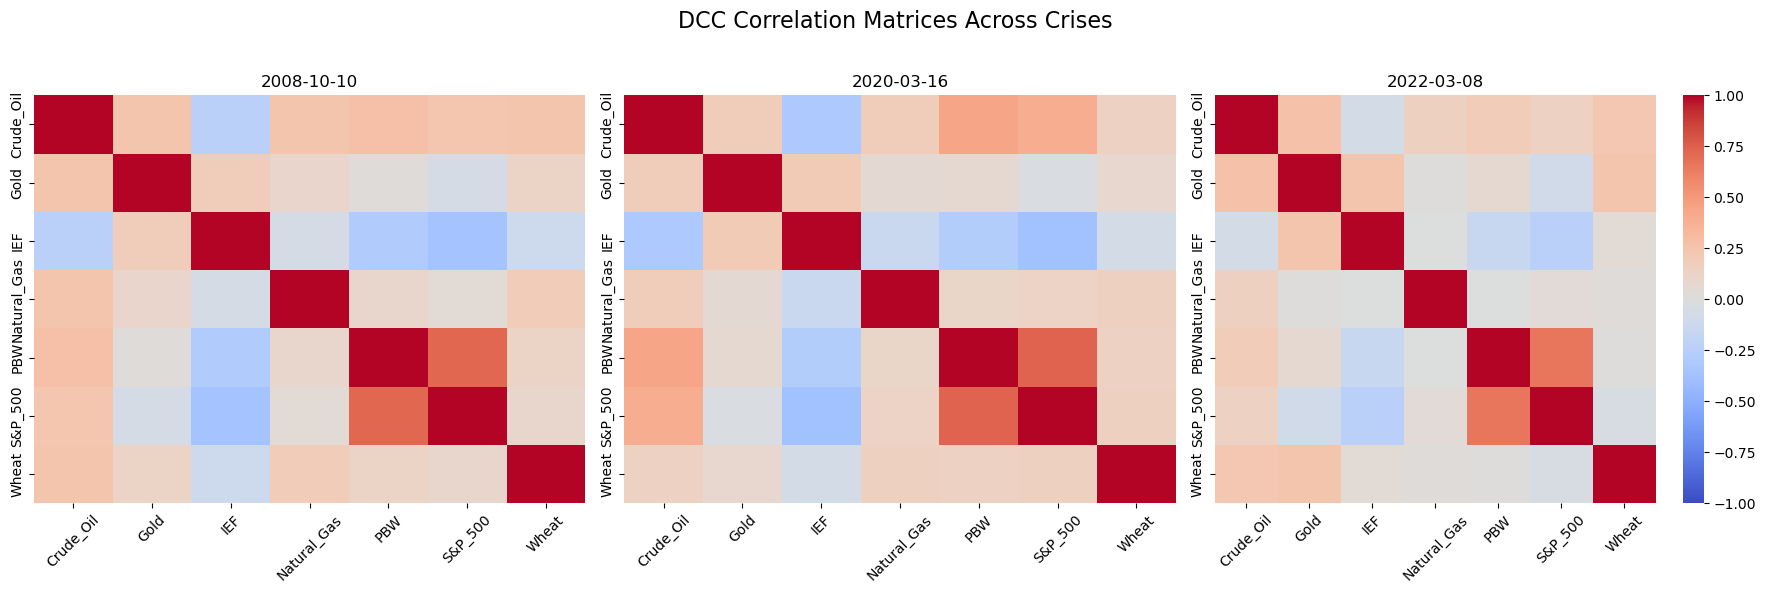

In [7]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
from pathlib import Path

# Setup paths
OUTPUT_DIR = Path('../outputs')

corr = pd.read_csv(OUTPUT_DIR / "dcc_correlations.csv", parse_dates=["Date"])

# Ensure a clean Pair column
if "Pair" not in corr.columns:
    if {"Asset1","Asset2"}.issubset(corr.columns):
        corr["Pair"] = corr["Asset1"].astype(str) + "–" + corr["Asset2"].astype(str)
    else:
        raise ValueError("Need either 'Pair' or both 'Asset1' and 'Asset2'.")

# Keep only true pairs like "A–B" or "A-B"
pair_re = r".+\s*[–-]\s*.+"
corr = corr[corr["Pair"].astype(str).str.fullmatch(pair_re)]
corr = corr.dropna(subset=["Date","Correlation","Pair"]).copy()

def split_pair(p):
    parts = re.split(r"\s*[–-]\s*", str(p).strip())
    return parts if len(parts) == 2 else [None, None]

def corr_matrix_at_date(cdf, target_date):
    target = pd.to_datetime(target_date)
    # nearest available date
    nearest = cdf.iloc[(cdf["Date"] - target).abs().argsort()[:1]]["Date"].iloc[0]
    df = cdf[cdf["Date"] == nearest]

    # collect assets from valid pairs only
    assets = sorted({a for p in df["Pair"].dropna().astype(str) for a in split_pair(p) if a})
    if not assets:
        raise ValueError(f"No valid pairs on {nearest}.")

    # init matrix
    mat = pd.DataFrame(1.0, index=assets, columns=assets)

    # fill off-diagonals safely
    for _, row in df.iterrows():
        a, b = split_pair(row["Pair"])
        if a and b and a in assets and b in assets:
            mat.loc[a, b] = row["Correlation"]
            mat.loc[b, a] = row["Correlation"]
    return nearest, mat

# Crisis dates
crisis_dates = ["2008-10-10","2020-03-16","2022-03-08"]

# Plot side-by-side heatmaps
fig, axes = plt.subplots(1, len(crisis_dates), figsize=(6*len(crisis_dates), 6))
for ax, d in zip(axes, crisis_dates):
    sel_date, M = corr_matrix_at_date(corr, d)
    sns.heatmap(M, vmin=-1, vmax=1, cmap="coolwarm", annot=False, ax=ax, cbar=(ax==axes[-1]))
    ax.set_title(str(sel_date.date()), fontsize=12)
    ax.tick_params(axis='x', rotation=45)
plt.suptitle("DCC Correlation Matrices Across Crises", fontsize=16)
plt.tight_layout(rect=[0,0,1,0.96])
plt.show()

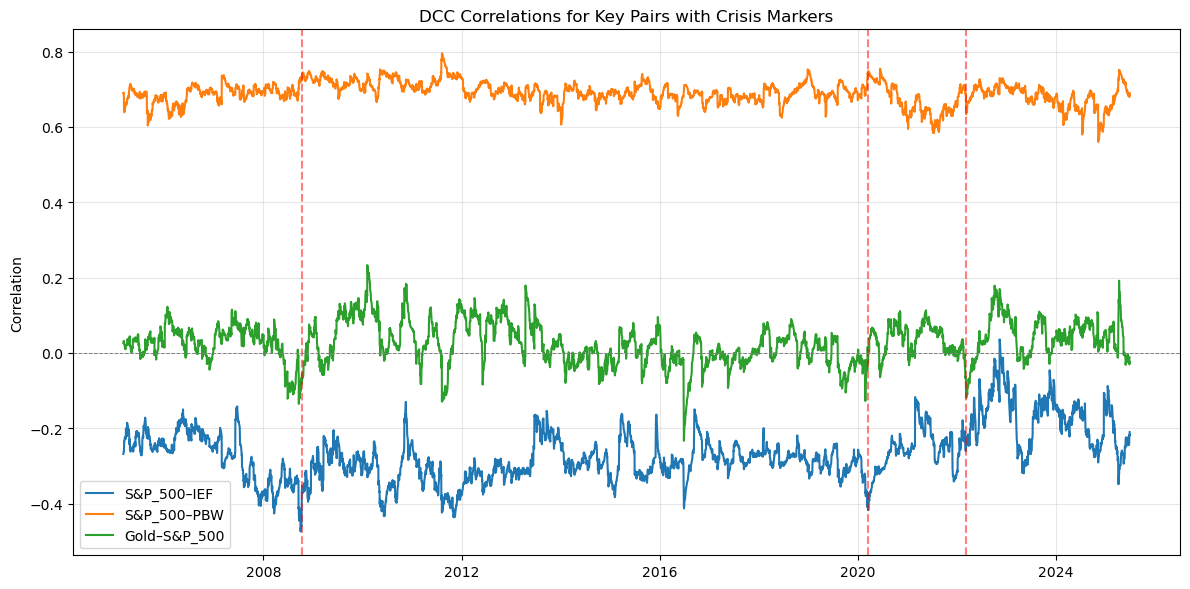

In [8]:
def get_pair_series(corr, asset_a, asset_b):
    # Return correlation time series for a given unordered pair
    mask = ((corr["Pair"] == f"{asset_a}–{asset_b}") |
            (corr["Pair"] == f"{asset_b}–{asset_a}"))
    ts = corr[mask].set_index("Date")["Correlation"].sort_index()
    return ts

def plot_key_pairs_with_crises_any_order(corr, pairs, crises):
    plt.figure(figsize=(12,6))
    for a, b in pairs:
        ts = get_pair_series(corr, a, b)
        if not ts.empty:
            plt.plot(ts.index, ts.values, label=f"{a}–{b}")
        else:
            print(f"⚠ No data found for {a}–{b}")
    
    for c in crises:
        plt.axvline(pd.to_datetime(c), color="red", linestyle="--", alpha=0.5)
    
    plt.axhline(0, color="gray", linestyle="--", lw=0.7)
    plt.legend()
    plt.title("DCC Correlations for Key Pairs with Crisis Markers")
    plt.ylabel("Correlation")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage
key_pairs = [
    ("S&P_500", "IEF"),
    ("S&P_500", "PBW"),
    ("Gold", "S&P_500")
]
crisis_dates = ["2008-10-10", "2020-03-16", "2022-03-08"]

plot_key_pairs_with_crises_any_order(corr, key_pairs, crisis_dates)


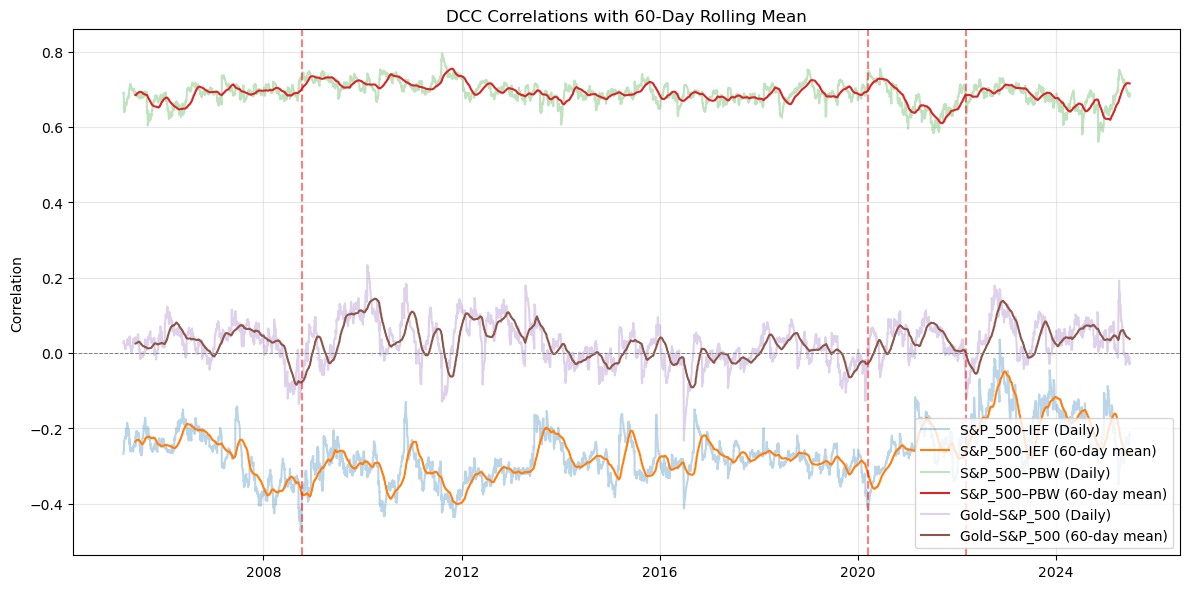

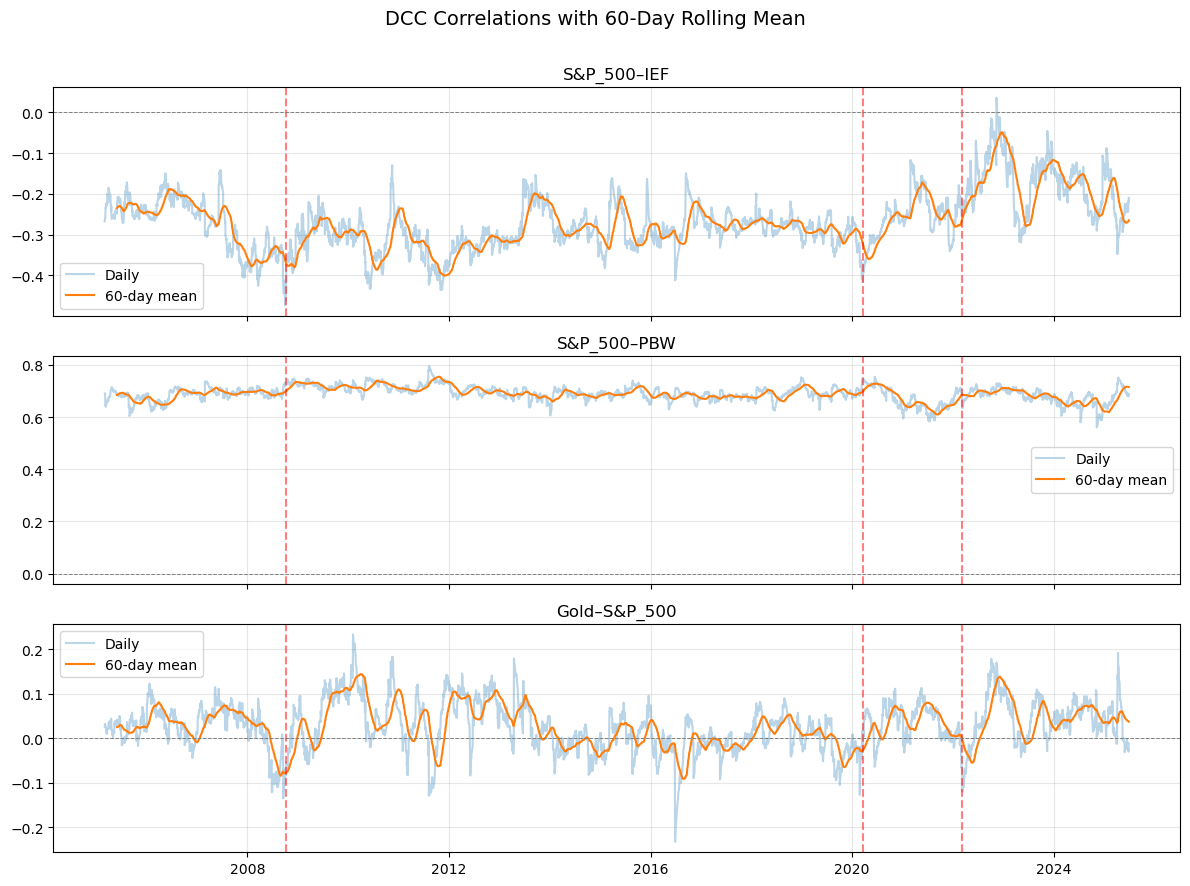

In [9]:
def get_pair_series(corr, asset_a, asset_b):
    mask = ((corr["Pair"] == f"{asset_a}–{asset_b}") |
            (corr["Pair"] == f"{asset_b}–{asset_a}"))
    ts = corr[mask].set_index("Date")["Correlation"].sort_index()
    return ts

def plot_key_pairs_with_crises_rolling(corr, pairs, crises, window=60):
    plt.figure(figsize=(12,6))
    for a, b in pairs:
        ts = get_pair_series(corr, a, b)
        if ts.empty:
            print(f"⚠ No data found for {a}–{b}")
            continue
        plt.plot(ts.index, ts.values, alpha=0.3, label=f"{a}–{b} (Daily)")
        plt.plot(ts.index, ts.rolling(window).mean(), label=f"{a}–{b} ({window}-day mean)")

    # Mark crisis dates
    for c in crises:
        plt.axvline(pd.to_datetime(c), color="red", linestyle="--", alpha=0.5)

    plt.axhline(0, color="gray", linestyle="--", lw=0.7)
    plt.legend()
    plt.title(f"DCC Correlations with {window}-Day Rolling Mean")
    plt.ylabel("Correlation")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

# Example usage
key_pairs = [
    ("S&P_500", "IEF"),
    ("S&P_500", "PBW"),
    ("Gold", "S&P_500")
]
crisis_dates = ["2008-10-10", "2020-03-16", "2022-03-08"]

plot_key_pairs_with_crises_rolling(corr, key_pairs, crisis_dates, window=60)

def plot_pairs_subplots_rolling(corr, pairs, crises, window=60):
    n_pairs = len(pairs)
    fig, axes = plt.subplots(n_pairs, 1, figsize=(12, 3 * n_pairs), sharex=True)

    # Ensure axes is iterable even if only 1 pair
    if n_pairs == 1:
        axes = [axes]

    for ax, (a, b) in zip(axes, pairs):
        # Get correlation series regardless of order
        mask = ((corr["Pair"] == f"{a}–{b}") | (corr["Pair"] == f"{b}–{a}"))
        ts = corr[mask].set_index("Date")["Correlation"].sort_index()

        if ts.empty:
            ax.text(0.5, 0.5, f"No data for {a}–{b}", ha="center", va="center")
            ax.set_axis_off()
            continue

        # Plot daily values
        ax.plot(ts.index, ts.values, alpha=0.3, label="Daily")
        # Plot rolling mean
        ax.plot(ts.index, ts.rolling(window).mean(), label=f"{window}-day mean")

        # Crisis markers
        for c in crises:
            ax.axvline(pd.to_datetime(c), color="red", linestyle="--", alpha=0.5)

        ax.axhline(0, color="gray", linestyle="--", lw=0.7)
        ax.set_title(f"{a}–{b}")
        ax.grid(True, alpha=0.3)
        ax.legend()

    plt.suptitle(f"DCC Correlations with {window}-Day Rolling Mean", fontsize=14)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

# Example usage
key_pairs = [
    ("S&P_500", "IEF"),
    ("S&P_500", "PBW"),
    ("Gold", "S&P_500")
]
crisis_dates = ["2008-10-10", "2020-03-16", "2022-03-08"]

plot_pairs_subplots_rolling(corr, key_pairs, crisis_dates, window=60)
